# **Project 2 | Content-Based and Collaborative Filtering**

# by Sandra Dela Cruz

In [99]:
# import libraries
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt

from sklearn.metrics.pairwise import cosine_similarity
from difflib import get_close_matches
from scipy.sparse import csr_matrix


In [100]:
# import dataset from GitHub
# original data source: https://grouplens.org/datasets/movielens/
!git clone https://github.com/lalaexplore/DATA-612.git

links = pd.read_csv('DATA-612/project 2/links.csv')
movies = pd.read_csv('DATA-612/project 2/movies.csv')
ratings = pd.read_csv('DATA-612/project 2/ratings.csv')
tags = pd.read_csv('DATA-612/project 2/tags.csv')

full_df = pd.merge(movies, ratings, on='movieId', how='left')

full_df.info()
full_df.head()

fatal: destination path 'DATA-612' already exists and is not an empty directory.
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100854 entries, 0 to 100853
Data columns (total 6 columns):
 #   Column     Non-Null Count   Dtype  
---  ------     --------------   -----  
 0   movieId    100854 non-null  int64  
 1   title      100854 non-null  object 
 2   genres     100854 non-null  object 
 3   userId     100836 non-null  float64
 4   rating     100836 non-null  float64
 5   timestamp  100836 non-null  float64
dtypes: float64(3), int64(1), object(2)
memory usage: 4.6+ MB


,movieId,title,genres,userId,rating,timestamp
0,1,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy,1.0,4.0,9.649827e+08
1,1,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy,5.0,4.0,8.474350e+08
2,1,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy,7.0,4.5,1.106636e+09
3,1,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy,15.0,2.5,1.510578e+09
4,1,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy,17.0,4.5,1.305696e+09


# Data Exploration and Preprocessing

In [101]:
# Let's see if we have any missing values
full_df.isnull().values.any()
full_df.isnull().sum().sum() # we have at least 54 missing values for userId, rating and timestamp
full_df[full_df.isnull().any(axis=1)].head()
# We have 54 missing values for userId, rating and timestamp. We will drop these rows for now since they are not useful for our analysis.


# Transform timestamp (just in case)
full_df['timestamp'] = pd.to_datetime(full_df['timestamp'], unit='s')
full_df['year'] = full_df['timestamp'].dt.year
full_df['month'] = full_df['timestamp'].dt.month
full_df['day'] = full_df['timestamp'].dt.day
full_df['hour'] = full_df['timestamp'].dt.hour
full_df['minute'] = full_df['timestamp'].dt.minute
full_df['second'] = full_df['timestamp'].dt.second

full_df.head()

,movieId,title,genres,userId,rating,timestamp,year,month,day,hour,minute,second
0,1,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy,1.0,4.0,2000-07-30 18:45:03,2000.0,7.0,30.0,18.0,45.0,3.0
1,1,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy,5.0,4.0,1996-11-08 06:36:02,1996.0,11.0,8.0,6.0,36.0,2.0
2,1,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy,7.0,4.5,2005-01-25 06:52:26,2005.0,1.0,25.0,6.0,52.0,26.0
3,1,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy,15.0,2.5,2017-11-13 12:59:30,2017.0,11.0,13.0,12.0,59.0,30.0
4,1,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy,17.0,4.5,2011-05-18 05:28:03,2011.0,5.0,18.0,5.0,28.0,3.0


In [102]:
# Drop missing values
full_df = full_df.dropna(subset=['userId'])

# Clean data
full_df['userId'] = full_df['userId'].astype(int)
full_df['movieId'] = full_df['movieId'].astype(int)
full_df['rating'] = full_df['rating'].astype(float)

full_df.head()


,movieId,title,genres,userId,rating,timestamp,year,month,day,hour,minute,second
0,1,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy,1,4.0,2000-07-30 18:45:03,2000.0,7.0,30.0,18.0,45.0,3.0
1,1,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy,5,4.0,1996-11-08 06:36:02,1996.0,11.0,8.0,6.0,36.0,2.0
2,1,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy,7,4.5,2005-01-25 06:52:26,2005.0,1.0,25.0,6.0,52.0,26.0
3,1,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy,15,2.5,2017-11-13 12:59:30,2017.0,11.0,13.0,12.0,59.0,30.0
4,1,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy,17,4.5,2011-05-18 05:28:03,2011.0,5.0,18.0,5.0,28.0,3.0


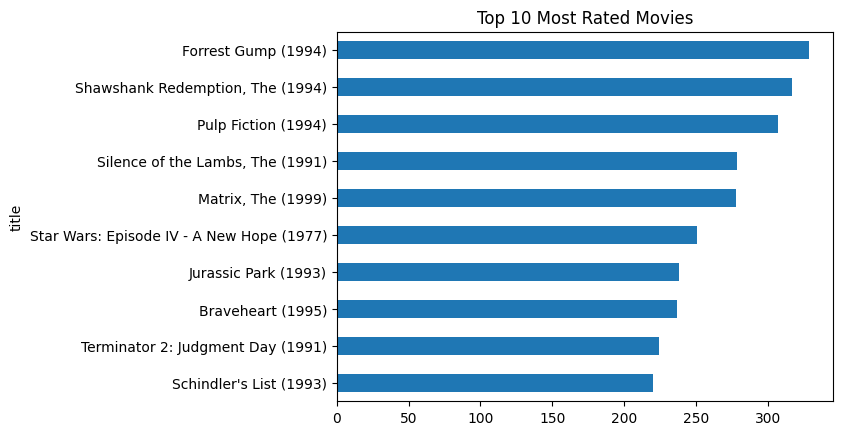

In [103]:
# Top 10 Most Rated Movies
top_movies = full_df['title'].value_counts().head(10)
top_movies.plot(kind='barh').invert_yaxis()

plt.title('Top 10 Most Rated Movies')
plt.show()

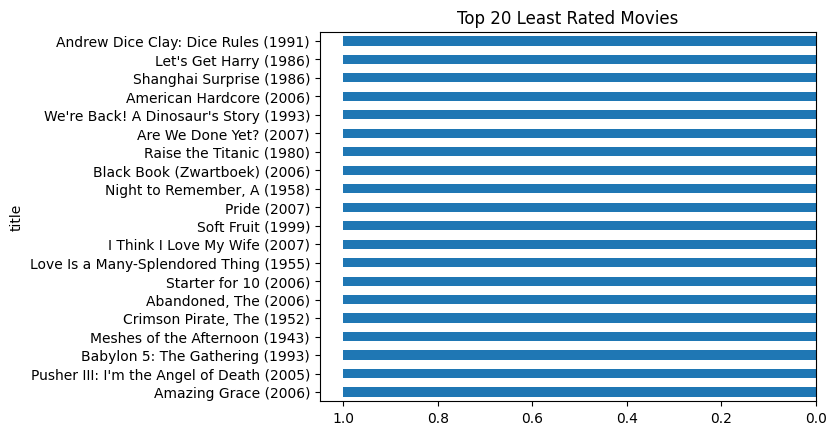

In [104]:
# Top 20 Least Rated Movies
least_movies = full_df['title'].value_counts().tail(20)
least_movies.plot(kind='barh').invert_xaxis()

plt.title('Top 20 Least Rated Movies')
plt.show()

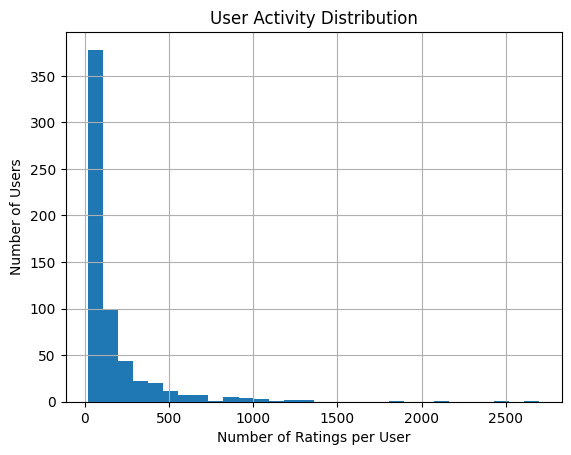

In [105]:
# User activity distribution
full_df['userId'].value_counts().hist(bins=30)

plt.title('User Activity Distribution')
plt.xlabel('Number of Ratings per User')
plt.ylabel('Number of Users')
plt.show()


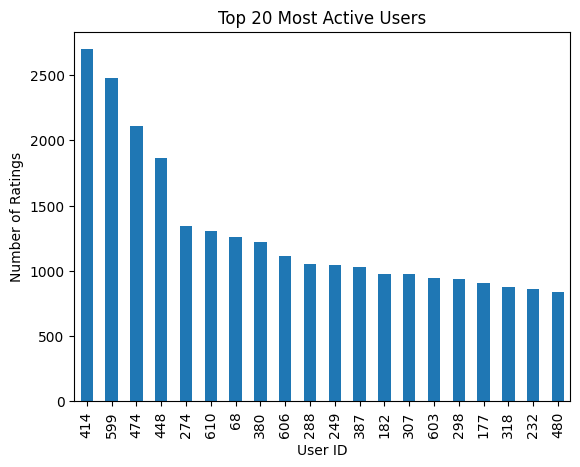

In [106]:
# Top 20 Most Active Users
user_counts = full_df['userId'].value_counts().head(20)
user_counts.plot(kind='bar')

plt.xlabel('User ID')
plt.ylabel('Number of Ratings')
plt.title('Top 20 Most Active Users')
plt.show()

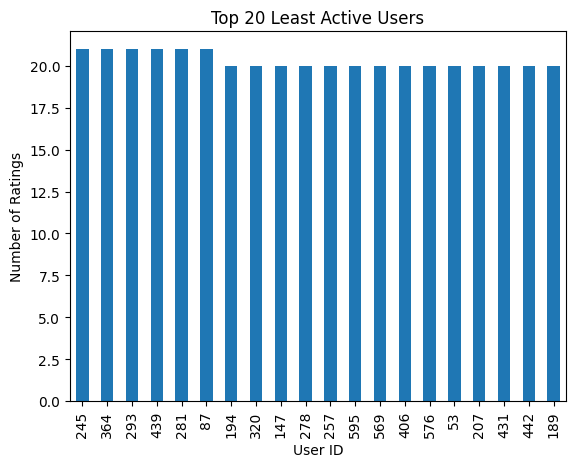

In [107]:
# Top 20 Most Least Active Users
least_active_users = full_df['userId'].value_counts().tail(20)
least_active_users.plot(kind='bar')

plt.xlabel('User ID')
plt.ylabel('Number of Ratings')
plt.title('Top 20 Least Active Users')
plt.show()


# Part 1: Item-Item Collaborative Filtering

In [108]:
# Build user-item matrix
user_item_matrix = full_df.pivot_table(
    index='userId',
    columns='movieId',
    values='rating'
)

user_item_matrix.head()

movieId,1,2,3,4,5,6,7,8,9,10,...,193565,193567,193571,193573,193579,193581,193583,193585,193587,193609
userId,,,,,,,,,,,,,,,,,,,,,
1,4.0,NaN,4.0,NaN,NaN,4.0,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,4.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [109]:
# Center the user-item matrix before cosine similarity
user_mean = user_item_matrix.mean(axis=1)

centered_matrix = user_item_matrix.sub(user_mean, axis=0)

centered_matrix.head()

movieId,1,2,3,4,5,6,7,8,9,10,...,193565,193567,193571,193573,193579,193581,193583,193585,193587,193609
userId,,,,,,,,,,,,,,,,,,,,,
1,-0.366379,NaN,-0.366379,NaN,NaN,-0.366379,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,0.363636,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [110]:
# Create sparse matrix from scipy.sparse to avoid NaNs problem
sparse_matrix = csr_matrix(centered_matrix.fillna(0).values) # 0 here has no meaning or value for sparse matrix

## Cosine Similarity

In [111]:
# Calculate cosine similarity
item_similarity = cosine_similarity(sparse_matrix.T) # we need to transpose the matrix to get item-item similarity instead of user-user similarity

item_similarity_df = pd.DataFrame(
    item_similarity,
    index=user_item_matrix.columns,
    columns=user_item_matrix.columns
)

item_similarity_df.head()

movieId,1,2,3,4,5,6,7,8,9,10,...,193565,193567,193571,193573,193579,193581,193583,193585,193587,193609
movieId,,,,,,,,,,,,,,,,,,,,,
1,1.000000,0.061511,0.051260,-0.036175,-0.140422,0.089142,-0.039411,0.003109,-0.105122,-0.053247,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0.061511,1.000000,0.056252,-0.106873,0.081893,-0.031387,0.020577,0.053926,-0.009668,-0.131687,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.051260,0.056252,1.000000,-0.035193,0.100357,-0.008854,0.060727,-0.057899,-0.011744,-0.107283,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,-0.036175,-0.106873,-0.035193,1.000000,0.021928,-0.017004,0.007410,0.024516,0.000000,0.118102,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
5,-0.140422,0.081893,0.100357,0.021928,1.000000,-0.052783,0.146651,0.002130,0.097845,0.026574,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [112]:
# Get the top 10 most similar movies for the movieId # 1 (Toy Story)
item_similarity_df[364].sort_values(ascending=False).head(10)

movieId
364     1.000000
588     0.356733
595     0.293266
4995    0.266820
356     0.256900
5991    0.249393
4306    0.246165
2571    0.241855
3675    0.241157
6942    0.236530
Name: 364, dtype: float64

In [113]:
# Create a mapping of movie IDs to titles
movie_titles = movies.set_index('movieId')['title']

# Get the movie ID for which we want to find similar movies
movie_id = item_similarity_df.index[364]

# Get movies similar to the input movie
similar_movies = (
    item_similarity_df[movie_id]
    .sort_values(ascending=False)
    .iloc[0:11]
)

for similar_movie_id, similarity_score in similar_movies.items():
    title = movie_titles.get(similar_movie_id, "Unknown")
    print(f"{title}: {similarity_score:.3f}")

Beverly Hills Cop III (1994): 1.000
Congo (1995): 0.412
Stealing Home (1988): 0.371
Outrageous Fortune (1987): 0.361
Purple Rain (1984): 0.360
9 1/2 Weeks (Nine 1/2 Weeks) (1986): 0.341
Wildcats (1986): 0.337
Boomerang (1992): 0.337
Clan of the Cave Bear, The (1986): 0.336
When Night Is Falling (1995): 0.332
Cheech & Chong's The Corsican Brothers (1984): 0.331


In [114]:
# Create title to movieId mapping lookup
title_to_movieId = movies.set_index('title')['movieId']
movie_titles = movies.set_index('movieId')['title']

# Choose movie by title
movie_title = "Amazing Grace (2006)"

# Convert title to movieId
movie_id = title_to_movieId[movie_titles]

# Create function to recommend movies by title
def recommend_by_title(movie_title, n=10):
    movie_id = title_to_movieId.get(movie_title)

    if movie_id is None:
        matches = get_close_matches(
            movie_title,
            title_to_movieId.index,
            n=5,
            cutoff=0.6
        )

        print(f"Movie title '{movie_title}' not found.")

        if matches:
            print("\nDid you mean:")
            for match in matches:
                print(f" - {match}")
        return
    
    similar_movies = (
        item_similarity_df[movie_id]
        .sort_values(ascending=False)
        .iloc[1:n+1]
    )

    print(f"\nRecommendations for '{movie_title}':")
    for similar_movie_id, score in similar_movies.items():
        print(f" - {movie_titles[similar_movie_id]}: {score:.3f}")

# Display the recommended movies
print("Recommended movies:")
recommend_by_title(movie_title)


Recommended movies:

Recommendations for 'Amazing Grace (2006)':
 - Sunflower (Xiang ri kui) (2005): 1.000
 - Chopper (2000): 1.000
 - Black Book (Zwartboek) (2006): 1.000
 - White Hunter, Black Heart (1990): 1.000
 - Snow Walker, The (2003): 1.000
 - Nines, The (2007): 1.000
 - Express, The (2008): 1.000
 - Amazing Grace (2006): 1.000
 - Appaloosa (2008): 1.000
 - Animal Factory (2000): 1.000


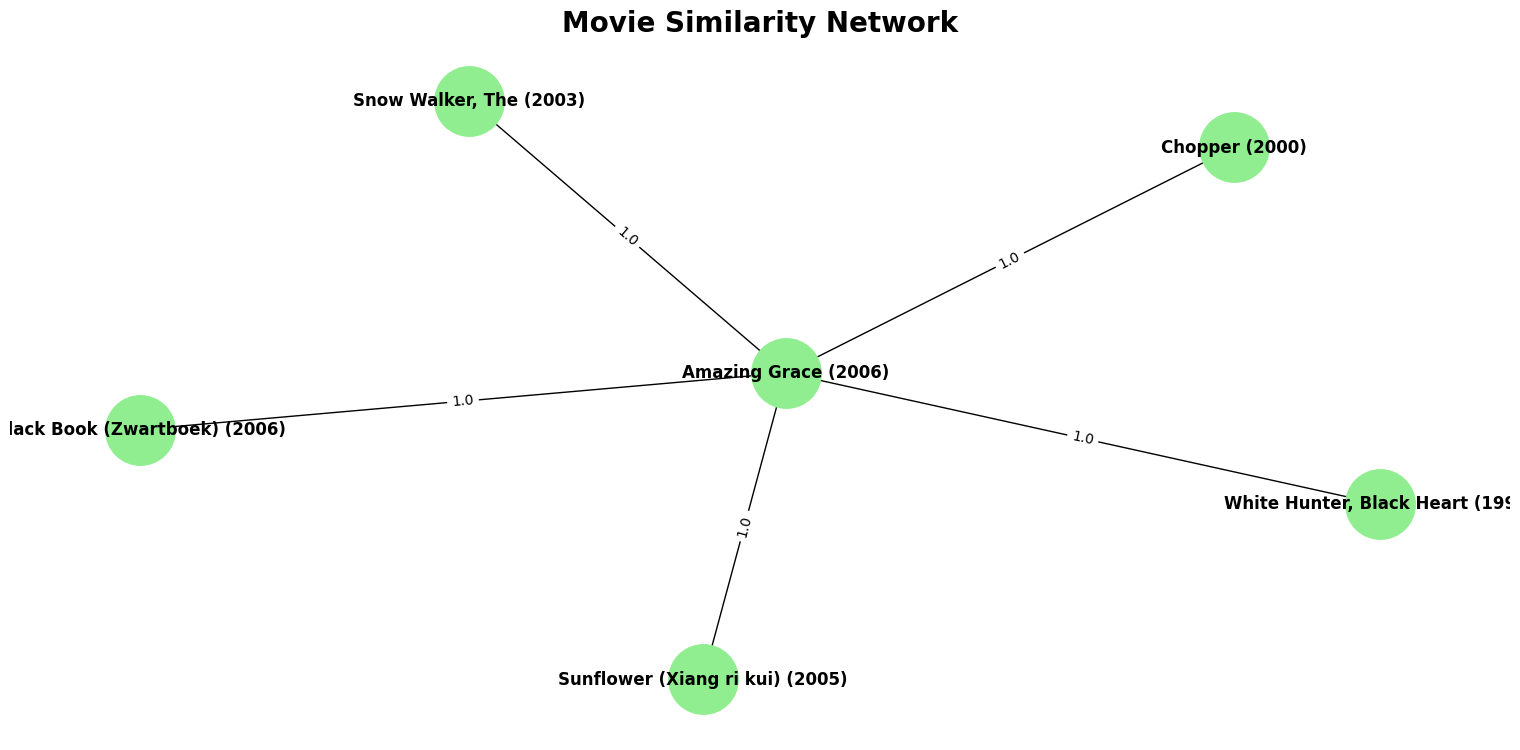

In [115]:
# Look up the movieId from the title
movie_id = title_to_movieId[movie_title]

# Create similar movies graph
top_similar = item_similarity_df[movie_id].sort_values(ascending=False).iloc[1:6]

G = nx.Graph()

# add main movie
G.add_node(movie_id)

# add similar movies
for sim_id, score in top_similar.items():
   G.add_edge(movie_id, sim_id, weight=score)


labels = {node: movie_titles.get(node, str(node)) for node in G.nodes()}

plt.figure(figsize=(15,7))

pos = nx.spring_layout(G)

nx.draw(
   G, 
   pos, 
   labels=labels, 
   node_size=2500, 
   node_color="lightgreen",
   font_size=12,
   font_weight="bold",
   width=1)

edge_labels = nx.get_edge_attributes(G, 'weight')
nx.draw_networkx_edge_labels(
   G, pos, edge_labels={k: round(v,2) for k,v in edge_labels.items()})

plt.title("Movie Similarity Network",
          fontsize=20,
          fontweight="bold")
plt.show()


# Part 2: User-User Collaborative Filtering
## Centered Cosine Similarity a.k.a. Pearson Correlation

In [116]:
# Compute similarity between users
user_similarity_pearson = centered_matrix.T.corr(method='pearson')

user_similarity_pearson.head()


userId,1,2,3,4,5,6,7,8,9,10,...,601,602,603,604,605,606,607,608,609,610
userId,,,,,,,,,,,,,,,,,,,,,
1,1.000000,NaN,0.079819,0.207983,0.268749,-0.291636,-0.118773,0.469668,0.918559,-0.037987,...,9.157371e-02,-1.705760e-17,-0.061503,-0.407556,-0.164871,0.066378,0.174557,0.268070,-0.175412,-0.032086
2,NaN,1.0,NaN,NaN,NaN,NaN,-0.991241,NaN,NaN,0.037796,...,-3.873468e-01,NaN,-1.000000,NaN,NaN,0.583333,NaN,-0.125000,NaN,0.623288
3,0.079819,NaN,1.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,0.433200,NaN,NaN,-0.791334,-0.333333,-0.395092,NaN,0.569562
4,0.207983,NaN,NaN,1.000000,-0.336525,0.148498,0.542861,0.117851,NaN,0.485794,...,-2.221127e-01,3.966413e-01,0.090090,-0.080296,0.400124,0.144603,0.116518,-0.170501,-0.277350,-0.043786
5,0.268749,NaN,NaN,-0.336525,1.000000,0.043166,0.158114,0.028347,NaN,-0.777714,...,-4.532467e-17,1.533034e-01,0.234743,0.067791,-0.364156,0.244321,0.231080,-0.020546,0.384111,0.040582


In [117]:
user_id = 5

# Create function to recommend movies by user in pearson correlation space
def recommend_for_user(user_id, n_user=5, n_recommendations=10):
    if user_id not in user_similarity_pearson.index:
        print(f"User {user_id} not found.")
        return
    # Get similar users
    similar_users = (
        user_similarity_pearson[user_id]
        .drop(user_id, errors='ignore')
        .sort_values(ascending=False)
        .iloc[1:n_user+1]
    )
    
    # Get ratings from similar users
    similar_ratings = user_item_matrix.loc[similar_users.index]
    
    # Weight ratings by similarity
    weighted_ratings = similar_ratings.T.dot(similar_users)
    
    # Top recommendations
    top_recs = weighted_ratings.sort_values(ascending=False).head(n_recommendations)

    print(f"\nRecommended movies for user {user_id}:\n",
          "As per Pearson Correlation")

    recommended_titles = [
    movie_titles.get(movie_id, "Unknown") + f": {score:.3f}"
    for movie_id, score in top_recs.items()
    ]

    return recommended_titles

# Display the recommended movies
recommend_for_user(user_id)




Recommended movies for user 5:
 As per Pearson Correlation


['Toy Story (1995): nan',
 'Jumanji (1995): nan',
 'Grumpier Old Men (1995): nan',
 'Waiting to Exhale (1995): nan',
 'Father of the Bride Part II (1995): nan',
 'Heat (1995): nan',
 'Sabrina (1995): nan',
 'Tom and Huck (1995): nan',
 'Sudden Death (1995): nan',
 'GoldenEye (1995): nan']

## Cosine Similarity

In [118]:
# Center the user-item matrix before cosine similarity
user_mean = user_item_matrix.mean(axis=1)

centered_matrix = user_item_matrix.sub(user_mean, axis=0)

centered_matrix.head()

movieId,1,2,3,4,5,6,7,8,9,10,...,193565,193567,193571,193573,193579,193581,193583,193585,193587,193609
userId,,,,,,,,,,,,,,,,,,,,,
1,-0.366379,NaN,-0.366379,NaN,NaN,-0.366379,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,0.363636,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [119]:
# Sparse matrix for user-item interactions
sparse_matrix = csr_matrix(centered_matrix.fillna(0).values)

# User-user similarity cosine
user_similarity_cosine = cosine_similarity(sparse_matrix)

# DataFrame for user-user similarity
user_similarity_cosine_df = pd.DataFrame(
    user_similarity_cosine,
    index=user_item_matrix.index,
    columns=user_item_matrix.index
)

user_similarity_cosine_df.head()

userId,1,2,3,4,5,6,7,8,9,10,...,601,602,603,604,605,606,607,608,609,610
userId,,,,,,,,,,,,,,,,,,,,,
1,1.000000,0.001265,0.000553,0.048419,0.021847,-0.045497,-0.006200,0.047013,0.019510,-0.008754,...,0.018127,-0.017172,-0.015221,-0.037059,-0.029121,0.012016,0.055261,0.075224,-0.025713,0.010932
2,0.001265,1.000000,0.000000,-0.017164,0.021796,-0.021051,-0.011114,-0.048085,0.000000,0.003012,...,-0.050551,-0.031581,-0.001688,0.000000,0.000000,0.006226,-0.020504,-0.006001,-0.060091,0.024999
3,0.000553,0.000000,1.000000,-0.011260,-0.031539,0.004800,0.000000,-0.032471,0.000000,0.000000,...,-0.004904,-0.016117,0.017749,0.000000,-0.001431,-0.037289,-0.007789,-0.013001,0.000000,0.019550
4,0.048419,-0.017164,-0.011260,1.000000,-0.029620,0.013956,0.058091,0.002065,-0.005874,0.051590,...,-0.037687,0.063122,0.027640,-0.013782,0.040037,0.020590,0.014628,-0.037569,-0.017884,-0.000995
5,0.021847,0.021796,-0.031539,-0.029620,1.000000,0.009111,0.010117,-0.012284,0.000000,-0.033165,...,0.015964,0.012427,0.027076,0.012461,-0.036272,0.026319,0.031896,-0.001751,0.093829,-0.000278


In [120]:
# Create function to recommend movies by user in cosine correlation space
def recommend_for_user2(user_id, n_user=5, n_recommendations=10):
    if user_id not in user_similarity_cosine_df.index:
        print(f"User {user_id} not found.")
        return
    # Get similar users
    similar_users = (
        user_similarity_cosine_df[user_id]
        .sort_values(ascending=False)
        .iloc[1:n_user+1]
    )
    
    # Get ratings from similar users
    similar_ratings = user_item_matrix.loc[similar_users.index]
    
    # Weight ratings by similarity
    weighted_ratings = similar_ratings.T.dot(similar_users)
    
    # Top recommendations
    top_recs = weighted_ratings.sort_values(ascending=False).head(n_recommendations)

    print(f"\nRecommended movies for user {user_id}:\n",
          "As per Cosine Similarity")

    recommended_titles = [
    movie_titles.get(movie_id, "Unknown") + f": {score:.3f}"
    for movie_id, score in top_recs.items()
    ]

    return recommended_titles

# Display the recommended movies
recommend_for_user2(user_id)


Recommended movies for user 5:
 As per Cosine Similarity


['Dances with Wolves (1990): 6.091',
 'Dumb & Dumber (Dumb and Dumber) (1994): 4.581',
 'Batman (1989): 4.191',
 'Toy Story (1995): nan',
 'Jumanji (1995): nan',
 'Grumpier Old Men (1995): nan',
 'Waiting to Exhale (1995): nan',
 'Father of the Bride Part II (1995): nan',
 'Heat (1995): nan',
 'Sabrina (1995): nan']

# Summary

This project explores collaborative filtering using both item-item and user-user approaches on a MovieLens dataset. The data is highly sparse, as only some users rate many movies while others have rated very few. To handle this sparsity efficiently, we use SciPy's sparse matrix representation.

We first implemented item-item collaborative filtering using cosine similarity. The user-item matrix is mean centered by user before converting it into a sparse matrix to support efficient computation with missing values. We then computed item-item similarities and built a recommendation function that returns movie titles (mapped from movieId) along with similarity scores relative to a given input movie. We also examined how the model behaves for less frequency rated movies, analysing the diversity of their recommended neighbors.

Next, we applied user-user collaborative filtering. In this case, we observed that the model can produce undefined (NaN) prediction scores for certain movies, particularly in highly sparse cases such as users with very few ratings (e.g., userId 5 in our dataset). This issue arises when there is insufficient overlap in rating histories between users, leading to zero denominators in the weighted aggregation step. As a result, predictions cannot be computed for some user-item pairs. This effect is more pronounced in sparse matrices, when shared ratings are limited.

Comparing Pearson correlation and cosine similarity, we find that both methods were affected by sparsity, though in slightly different ways. Cosine similarity tends to produce more stable predictions in sparse settings due to its geometric normalization, whereas Pearson correlation can be more sensitive to the availability of co-rated items after mean-centering.